In [ ]:
# ==========================================
# AUTOMOTIVE PROCUREMENT ANALYTICS
# ==========================================

## STEP 1: Project Overview
## ==========================================

# This project analyzes automotive procurement data from 2020-2025.

# The objective is to:
    # - Analize supplier performance
    # - Analyze OEM distribution
    # - Evaluate project volumes
    # - Identify procurement trends over time
    # - Visualize procurement KPIs
    
    # Tools used:
    # - Python
    # - Pandas
    # - Matplotlib
    # - Jupyter Notebook

In [18]:
## STEP 2: Data Loading
## ==========================================

import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_excel("Automotive_Procurement_Analytics_2020_2025.xlsx")
df.head(10)

,Project_ID,OEM,Project_Name,Commodity,Component,Supplier,Supplier_Country,Plant_Location,Buyer,Annual_Volume,Target_Price_EUR,Project_Status,RFQ_Date,Nomination_Date,SOP_Date
0,PRJ-10001,Renault,Project_1,PCB,Sensor,Yazaki,Serbia,Stuttgart,Luka,8794,22.74,Closed,2024-08-21,2025-01-30,2026-02-01
1,PRJ-10002,Volvo,Project_2,Mechatronics,Motor,Valeo,Romania,Stuttgart,Nikola,481142,8.25,SOP,2021-05-04,2021-10-26,2023-03-29
2,PRJ-10003,Volvo,Project_3,PCB,PCB,Forvia,Serbia,Timisoara,Luka,67290,35.45,RFQ,2024-11-28,2025-03-22,2026-05-28
3,PRJ-10004,Mercedes,Project_4,Plastic,Harness,Forvia,France,Timisoara,Marko,384520,215.34,RFQ,2020-03-21,2020-08-14,2022-01-19
4,PRJ-10005,Stellantis,Project_5,PCB,Connector,Forvia,Serbia,Prague,Philipp,325631,13.95,Industrialization,2021-03-12,2021-05-13,2022-04-27
5,PRJ-10006,Ford,Project_6,Plastic,Housing,Lear,Germany,Lyon,Damon,203506,160.82,SOP,2024-07-05,2024-10-11,2025-04-09
6,PRJ-10007,Ford,Project_7,Mechatronics,Battery Pack,Bosch,Italy,Stuttgart,Philipp,392301,140.36,Closed,2021-09-24,2022-02-13,2023-01-19
7,PRJ-10008,VW,Project_8,Battery,Sensor,Magna,Serbia,Novi Sad,Philipp,470539,105.68,Closed,2023-11-26,2024-03-23,2025-05-25
8,PRJ-10009,Stellantis,Project_9,Plastic,Display,Lear,Romania,Novi Sad,Luka,31945,46.49,SOP,2025-02-09,2025-07-04,2026-11-29
9,PRJ-10010,Audi,Project_10,Electronics,Display,Yazaki,Serbia,Stuttgart,Damon,433838,217.59,Nomination,2020-01-04,2020-02-04,2021-01-16


In [9]:
## STEP 3: Data Understanding
## ==========================================

df.info()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Project_ID        1000 non-null   str           
 1   OEM               1000 non-null   str           
 2   Project_Name      1000 non-null   str           
 3   Commodity         1000 non-null   str           
 4   Component         1000 non-null   str           
 5   Supplier          1000 non-null   str           
 6   Supplier_Country  1000 non-null   str           
 7   Plant_Location    1000 non-null   str           
 8   Buyer             1000 non-null   str           
 9   Annual_Volume     1000 non-null   int64         
 10  Target_Price_EUR  1000 non-null   float64       
 11  Project_Status    1000 non-null   str           
 12  RFQ_Date          1000 non-null   datetime64[us]
 13  Nomination_Date   1000 non-null   datetime64[us]
 14  SOP_Date          1000 non-null   da

(1000, 15)

In [10]:
## STEP 4: Missing Values Check
## ==========================================

df.isnull().sum()

Project_ID          0
OEM                 0
Project_Name        0
Commodity           0
Component           0
Supplier            0
Supplier_Country    0
Plant_Location      0
Buyer               0
Annual_Volume       0
Target_Price_EUR    0
Project_Status      0
RFQ_Date            0
Nomination_Date     0
SOP_Date            0
dtype: int64

In [11]:
## STEP 5: Duplicate Records Check
## ==========================================

df.duplicated().sum()

np.int64(0)

In [ ]:
### Observation

# No missing values were identified in the dataset.
# The dataset is suitable for further analysis without additional data cleaning.

In [12]:
## STEP 6: Date Columns Validation
## ==========================================

df[["RFQ_Date", "Nomination_Date", "SOP_Date"]].head()

,RFQ_Date,Nomination_Date,SOP_Date
0,2024-08-21,2025-01-30,2026-02-01
1,2021-05-04,2021-10-26,2023-03-29
2,2024-11-28,2025-03-22,2026-05-28
3,2020-03-21,2020-08-14,2022-01-19
4,2021-03-12,2021-05-13,2022-04-27


In [13]:
## STEP 7: Extract Year
## ==========================================

# To enable time-based analysis, a new column containing the RFQ year is created.

df["RFQ_Year"] = df["RFQ_Date"].dt.year
df[["RFQ_Date", "RFQ_Year"]].head()

,RFQ_Date,RFQ_Year
0,2024-08-21,2024
1,2021-05-04,2021
2,2024-11-28,2024
3,2020-03-21,2020
4,2021-03-12,2021


In [14]:
## STEP 8: Projects Per Year
## ==========================================

# This analysis shows how many projects were launched each year between 2020 and 2025.

projects_per_year = df["RFQ_Year"].value_counts()
print(projects_per_year)

RFQ_Year
2022    180
2024    173
2021    172
2023    165
2020    163
2025    147
Name: count, dtype: int64


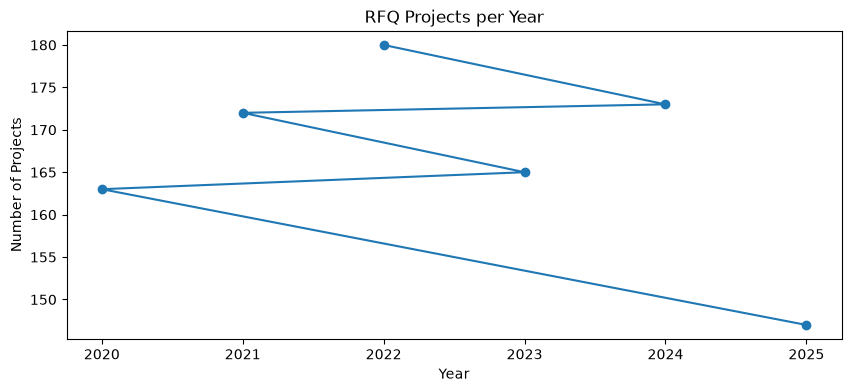

In [42]:
## STEP 9: RFQ Trend by Year
## ==========================================

# The following chart visualizes the number of procurement projects initiated each year.

projects_per_year.plot(
    kind="line",
    figsize=(10, 4),
    marker="o"
    )
plt.title("RFQ Projects per Year")
plt.xlabel("Year")
plt.ylabel("Number of Projects")
plt.show()

In [ ]:
## Observation
## ==========================================

# The chart illustrates the annual project distribution between 2020 and 2025.
# Further analysis can identify whether project activity increased or decreased over time.

In [20]:
## STEP 10: Monthly RFQ Trend Analysis
## ==========================================

# To better understand procurement activity over time, the RFQ date is analyzed at the monthly level.
# This allows us to identify periods with increased or decreased project activity.

df["RFQ_Month"] = df["RFQ_Date"].dt.to_period("M")
df[["RFQ_Date", "RFQ_Month"]].head()

,RFQ_Date,RFQ_Month
0,2024-08-21,2024-08
1,2021-05-04,2021-05
2,2024-11-28,2024-11
3,2020-03-21,2020-03
4,2021-03-12,2021-03


In [21]:
## STEP 11: Project Count by Month
## ==========================================

# The following analysis counts the number of RFQs created each month.

monthly_projects = (
    df["RFQ_Month"].value_counts().sort_index()
)
monthly_projects.head()

RFQ_Month
2020-01    11
2020-02    19
2020-03    16
2020-04     8
2020-05    11
Freq: M, Name: count, dtype: int64

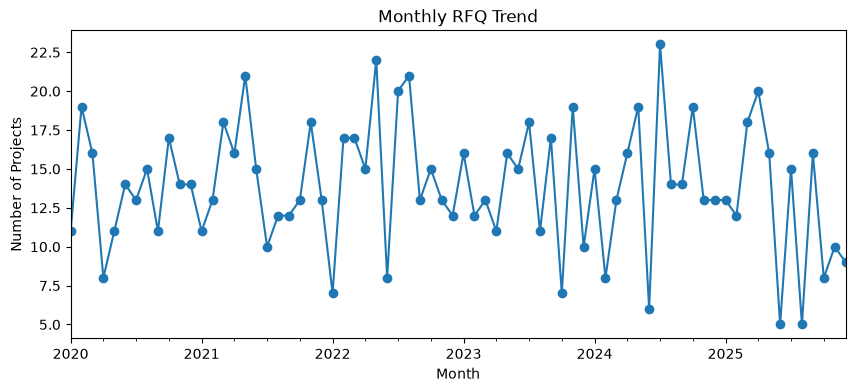

In [43]:
## STEP 12: Monthly RFQ Trend Visualization
## ==========================================

# This chart illustrates procurement project activity over time at the monthly level.

monthly_projects.plot(
    kind="line",
    figsize=(10, 4),
    marker="o"
    )

plt.title("Monthly RFQ Trend")
plt.xlabel("Month")
plt.ylabel("Number of Projects")
plt.show()


In [ ]:
## Observation
## ==========================================

# The chart visualizes monthly procurement activity between 2020 and 2025.
# Potential seasonal effects and fluctuations in project launches can be investigated in future analyses.

In [23]:
## STEP 13: Supplier Analysis
## ==========================================

# The objective of this analysis is to identify suppliers with the highest number of projects.

supplier_projects = (
    df["Supplier"].value_counts()
    )
supplier_projects

Supplier
Forvia         115
Aptiv          114
Bosch          107
Lear           105
Yazaki         102
Magna          102
Valeo           95
Continental     91
ZF              87
Denso           82
Name: count, dtype: int64

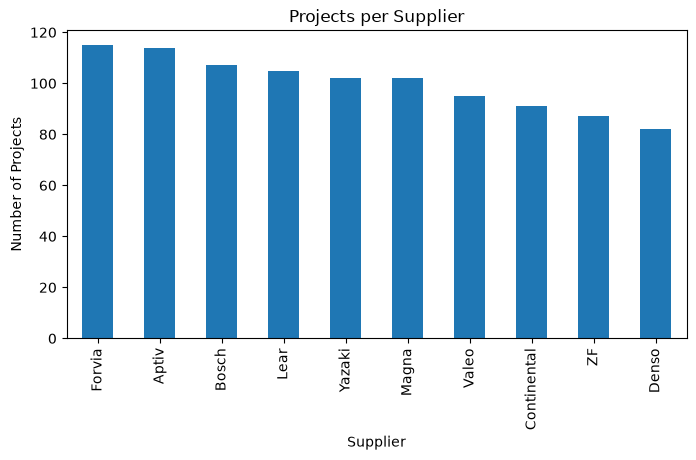

In [44]:
## STEP 14: Supplier Analysis / Visualization
## ==========================================

supplier_projects.plot(
    kind="bar",
    figsize=(8, 4)
    )

plt.title("Projects per Supplier")
plt.xlabel("Supplier")
plt.ylabel("Number of Projects")
plt.show()

In [ ]:
## Observation
## ==========================================

# The chart highlights suppliers with the highest project allocation.
# These suppliers may represent strategic sourcing partners and deserve further analysis.

In [25]:
## STEP 15: Supplier Performance Analysis
## ==========================================

# The objective of this analysis is to evaluate supplier performance using key procurement indicators:
    # - Number of Projects
    # - Average Annual Volume
    # - Average Target Price

supplier_summary = df.groupby("Supplier").agg(
    Projects=("Project_ID", "count"),
    Avg_Volume=("Annual_Volume", "mean"),
    Avg_Target_Price=("Target_Price_EUR", "mean")
)
supplier_summary

,Projects,Avg_Volume,Avg_Target_Price
Supplier,,,
Aptiv,114,248189.245614,133.235175
Bosch,107,248875.785047,117.789346
Continental,91,248844.571429,119.258022
Denso,82,265064.414634,139.464024
Forvia,115,251381.808696,121.914000
Lear,105,277402.800000,123.981429
Magna,102,239368.274510,118.936275
Valeo,95,245912.336842,126.472842
Yazaki,102,257000.323529,133.602059


In [26]:
## STEP 16: Top 5 Suppliers by Project Count
## ==========================================

# Suppliers are ranked according to the number of assigned projects.

top5_suppliers = supplier_summary.sort_values(
    by="Projects",
    ascending=False
).head(5)
top5_suppliers

,Projects,Avg_Volume,Avg_Target_Price
Supplier,,,
Forvia,115,251381.808696,121.914000
Aptiv,114,248189.245614,133.235175
Bosch,107,248875.785047,117.789346
Lear,105,277402.800000,123.981429
Yazaki,102,257000.323529,133.602059


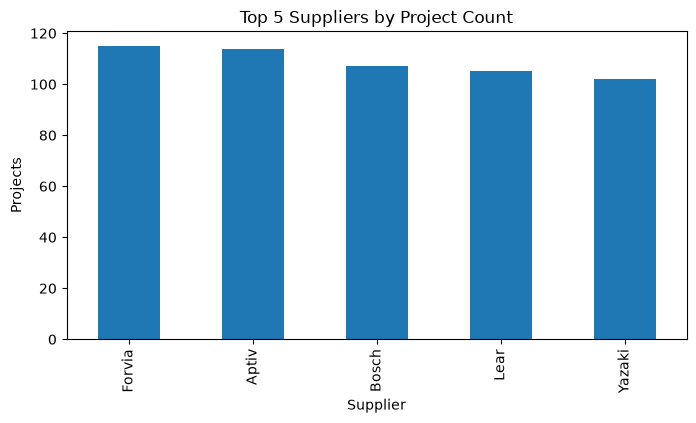

In [41]:
## STEP 17: Top 5 Suppliers by Project Count - Visualization
## ==========================================

top5_suppliers["Projects"].plot(
    kind="bar",
    figsize=(8, 4)
)
plt.title("Top 5 Suppliers by Project Count")
plt.xlabel("Supplier")
plt.ylabel("Projects")
plt.show()

In [ ]:
## Observation
## ==========================================

# The analysis identifies the five suppliers with the highest project allocation.
# These suppliers may represent strategic sourcing partners and account for a significant portion of the procurement portfolio.
# Further analysis should focus on volume distribution and pricing competitiveness.

In [29]:
## STEP 18: OEM Distribution Analysis
## ==========================================

# This analysis evaluates the number of procurement projects assigned to each OEM customer.

oem_summary = df["OEM"].value_counts()
oem_summary

OEM
VW            146
Audi          134
Ford          132
Volvo         127
Mercedes      120
Stellantis    119
BMW           113
Renault       109
Name: count, dtype: int64

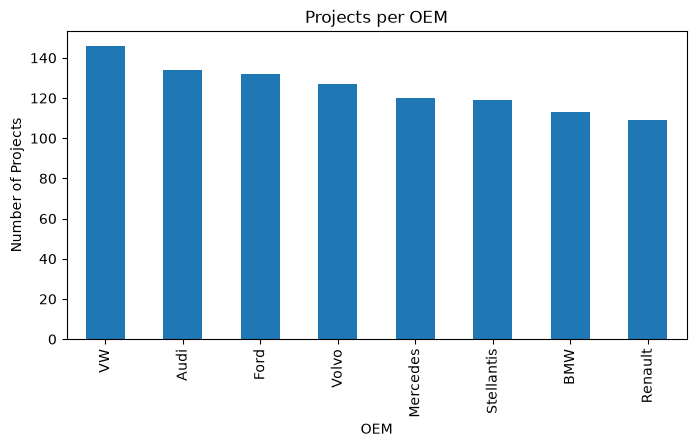

In [45]:
## STEP 19: OEM Distribution Analysis - Visualization
## ==========================================

oem_summary.plot(
    kind="bar",
    figsize=(8, 4)
)
plt.title("Projects per OEM")
plt.xlabel("OEM")
plt.ylabel("Number of Projects")
plt.show()

In [31]:
## STEP 20: Commodity Analysis
## ==========================================

# This analysis evaluates the distribution of procurement projects across different commodity groups.
# The objective is to identify the most important sourcing categories within the portfolio.

commodity_summary = df["Commodity"].value_counts()
commodity_summary

Commodity
PCB             177
Plastic         176
Electronics     174
Mechatronics    164
Metal           159
Battery         150
Name: count, dtype: int64

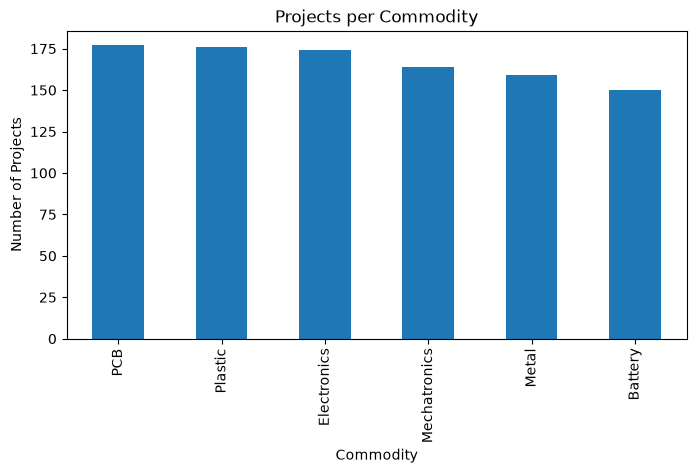

In [46]:
## STEP 21: Commodity Analysis - Visualization
## ==========================================

# This analysis evaluates the distribution of procurement projects across different commodity groups.
# The objective is to identify the most important sourcing categories within the portfolio.

commodity_summary.plot(
    kind="bar",
    figsize=(8, 4)
    )
plt.title("Projects per Commodity")
plt.xlabel("Commodity")
plt.ylabel("Number of Projects")
plt.show()

In [ ]:
## Observation
## ==========================================

# The analysis shows how procurement projects are distributed across commodity categories.
# The highest-volume commodity groups may require increased sourcing effort and supplier management attention.

In [33]:
## STEP 22: Average Target Price by Supplier
## ==========================================

# This analysis compares suppliers based on their average target price levels.

avg_price_supplier = df.groupby("Supplier")[
    "Target_Price_EUR"
].mean()
avg_price_supplier = avg_price_supplier.sort_values(
    ascending=False
)
avg_price_supplier

Supplier
Denso          139.464024
Yazaki         133.602059
Aptiv          133.235175
Valeo          126.472842
Lear           123.981429
Forvia         121.914000
Continental    119.258022
Magna          118.936275
ZF             118.239195
Bosch          117.789346
Name: Target_Price_EUR, dtype: float64

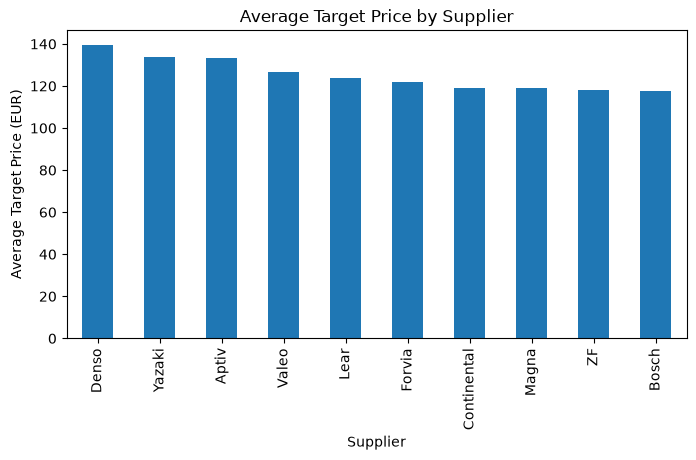

In [47]:
## STEP 23: Average Target Price by Supplier - Visualization
## ==========================================

avg_price_supplier.plot(
    kind="bar",
    figsize=(8, 4)
    )
plt.title("Average Target Price by Supplier")
plt.xlabel("Supplier")
plt.ylabel("Average Target Price (EUR)")
plt.show()

In [35]:
## STEP 24: Average Annual Volume by Supplier
## ==========================================

# This analysis compares suppliers based on their average annual project volumes.

avg_volume_supplier = df.groupby("Supplier")[
    "Annual_Volume"
].mean()
avg_volume_supplier = avg_volume_supplier.sort_values(
    ascending=False
)
avg_volume_supplier

Supplier
Lear           277402.800000
Denso          265064.414634
Yazaki         257000.323529
Forvia         251381.808696
Bosch          248875.785047
Continental    248844.571429
Aptiv          248189.245614
Valeo          245912.336842
Magna          239368.274510
ZF             216084.229885
Name: Annual_Volume, dtype: float64

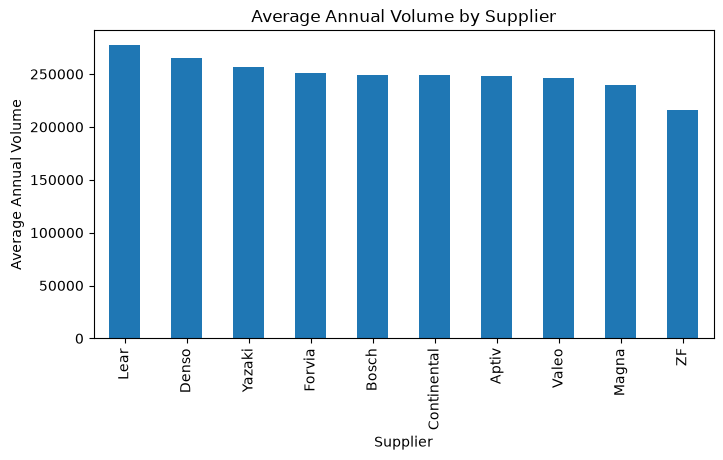

In [48]:
## STEP 25: Average Annual Volume by Supplier - Visualization
## ==========================================

avg_volume_supplier.plot(
    kind="bar",
    figsize=(8, 4)
)
plt.title("Average Annual Volume by Supplier")
plt.xlabel("Supplier")
plt.ylabel("Average Annual Volume")
plt.show()

In [37]:
## STEP 26: Procurement KPI Dashboard
## ==========================================

# The following summary table consolidates key supplier performance indicators.

dashboard = df.groupby("Supplier").agg(
    Projects=("Project_ID", "count"),
    Avg_Volume=("Annual_Volume", "mean"),
    Avg_Target_Price=("Target_Price_EUR", "mean")
    )
dashboard = dashboard.sort_values(
    by="Projects",
    ascending=False
    )
dashboard

,Projects,Avg_Volume,Avg_Target_Price
Supplier,,,
Forvia,115,251381.808696,121.914000
Aptiv,114,248189.245614,133.235175
Bosch,107,248875.785047,117.789346
Lear,105,277402.800000,123.981429
Yazaki,102,257000.323529,133.602059
Magna,102,239368.274510,118.936275
Valeo,95,245912.336842,126.472842
Continental,91,248844.571429,119.258022
ZF,87,216084.229885,118.239195


In [38]:
## STEP 27: Export Results
## ==========================================

# The KPI dashboard is exported to Excel for reporting purposes.

dashboard.to_excel(
    "Procurement_KPI_Dashboard.xlsx"
)

In [ ]:
## STEP 28: Key Findings
## ==========================================

### Supplier Analysis
# - Several suppliers account for a significant share of the project portfolio.
# - Project allocation varies considerably across suppliers.

### OEM Analysis
# - Project distribution is relatively balanced across OEM customers.
# - Certain OEMs generate higher sourcing activity.

### Commodity Analysis
# - A limited number of commodity groups dominate the procurement portfolio.
# - These categories represent key sourcing focus areas.

### Time Trend Analysis
# - RFQ project activity fluctuates across the 2020–2025 period.
# - Monthly and yearly analysis can support resource planning and workload forecasting.

In [ ]:
## STEP 29: Conclusion
## ==========================================

# This project demonstrates the use of Python, Pandas, and Matplotlib for procurement data analysis.
# The analysis covered:
    # - Data quality assessment
    # - Supplier performance evaluation
    # - OEM portfolio analysis
    # - Commodity analysis
    # - RFQ trend visualization
    # - KPI dashboard creation
    # - Excel report generation
# The project highlights how procurement reporting tasks can be automated and transformed into actionable business insights using Python.